# SwissLipids PKN mapping — Morita et al.

**Goal:** Evaluate how many Morita lipids can be mapped to entries that  
have enzyme/protein annotations in the SwissLipids Prior Knowledge Network (PKN).  

**Key difference from `mapping_swisslipids.ipynb`:**  
That notebook checked coverage against *all* SwissLipids entries (`lipids.tsv.gz`).  
This notebook uses `lipids2uniprot.tsv`, which contains only the subset of lipids  
connected to at least one UniProtKB enzyme — i.e. the actionable PKN nodes.

| Input | Column used |
|---|---|
| `data/processed/goslin_Morita.csv` | `original_name`, `class_name` |
| SwissLipids `lipids2uniprot.tsv` (fetched at runtime) | `abbreviations` |

In [121]:
import re
import gzip, csv, io
import urllib.request
import pandas as pd
from IPython.display import display


## Step 1 — Load Morita lipid list

In [122]:
df_goslin = pd.read_csv('../data/processed/goslin_Morita.csv')

# Keep only columns needed; fill missing class from first token of original_name
df = df_goslin[['original_name', 'class_name']].copy()
def extract_class(name):
    m = re.match(r'^[A-Za-z]+', name)
    return m.group() if m else 'Unknown'

df['class_name'] = df['class_name'].fillna(df['original_name'].map(extract_class))

print(f'Total Morita lipids: {len(df)}')
print('Classes:', sorted(df['class_name'].unique()))


Total Morita lipids: 1290
Classes: ['CE', 'Cer', 'Cholesterol', 'DG', 'FA', 'HexCer', 'LPC', 'LPE', 'MG', 'PA', 'PC', 'PE', 'PG', 'PI', 'PS', 'SM', 'TG']


## Step 2 — Build PKN abbreviation set from `lipids2uniprot.tsv`

Each row in `lipids2uniprot.tsv` represents a lipid–enzyme (UniProtKB) association.  
The `abbreviations` column may contain multiple names separated by ` | `.  
We expand all of them into a flat set.

In [123]:
SL_UNIPROT_URL = (
    'https://www.swisslipids.org/api/file.php'
    '?cas=download_files&file=lipids2uniprot.tsv'
)

print('Fetching lipids2uniprot.tsv from SwissLipids ...')
req = urllib.request.Request(SL_UNIPROT_URL,
                             headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req, timeout=60) as r:
    raw = r.read()

pkn_abbr_set = set()
with gzip.open(io.BytesIO(raw), 'rt', encoding='utf-8') as f:
    reader = csv.DictReader(f, delimiter='\t')
    for row in reader:
        for a in row.get('abbreviations', '').split(' | '):
            a = a.strip()
            if a:
                pkn_abbr_set.add(a)

print(f'PKN abbreviations loaded: {len(pkn_abbr_set):,}')


Fetching lipids2uniprot.tsv from SwissLipids ...
PKN abbreviations loaded: 352,601


## Step 3 — Normalize Morita lipid names to PKN format

Only **syntactic** normalization is applied here:  
removing spaces between class name and chain, and wrapping chains in parentheses.  
Chain separators (`_`) and biological prefixes (`d`, `t`) are left as-is.  
Granularity adjustments (e.g. `_`→`/`, adding `d` prefix, SN-position expansion) are out of scope here.

| Class | Morita format | Normalized (PKN candidate) |
|---|---|---|
| TG | `TG(12:0)(14:0)(18:2)` | `TG(12:0_14:0_18:2)` |
| DG | `DG 12:0_16:0` | `DG(12:0_16:0)` |
| PC / PE / PA / PG / PI / PS | `PC 14:0_16:0` | `PC(14:0_16:0)` |
| Cer | `Cer d18:1_14:0` | `Cer(d18:1_14:0)` |
| SM | `SM 30:1` | `SM(30:1)` |
| CE / FA | `CE(18:0)` | `CE(18:0)` (unchanged) |
| MG | `MG 14:0` | `MG(14:0)` |
| LPC / LPE | `LPC 14:0` | `LPC(14:0)` |
| HexCer | `HexCer d18:1_16:0` | `HexCer(d18:1_16:0)` |

In [124]:
def normalize_for_pkn(original_name, class_name):
    """
    Syntactic normalization only:
    - Remove space between class name and chain info
    - Wrap chain in parentheses
    - TG: collapse multiple (chain) groups into one underscore-separated key
    No granularity changes: _ separators, d/t prefixes, SN-position expansion
    are intentionally left untouched.
    """
    name = original_name.strip()

    # TG: TG(12:0)(14:0)(18:2) -> TG(12:0_14:0_18:2)
    # (multiple ()-groups -> single underscore-joined group — pure syntax reformat)
    if class_name == 'TG':
        chains = re.findall(r'\(([^)]+)\)', name)
        if len(chains) == 3:
            return [f'TG({"_".join(chains)})']

    # All other classes: remove space, wrap in parentheses, keep everything else
    # Pattern: CLASS_NAME <space> CHAIN_INFO  ->  CLASS_NAME(CHAIN_INFO)
    m = re.match(r'^([A-Za-z]+)\s+(\S+.*)$', name)
    if m:
        cls, chain = m.group(1), m.group(2).strip()
        return [f'{cls}({chain})']

    # Already has parentheses (CE, FA, etc.) — return as-is
    return [name]


df['pkn_candidates'] = df.apply(
    lambda row: normalize_for_pkn(row['original_name'], row['class_name']), axis=1
)
df['pkn_key'] = df['pkn_candidates'].apply(
    lambda cands: next((c for c in cands if c in pkn_abbr_set), None)
)
df['mapped'] = df['pkn_key'].notna()

print('Normalization done.')
print(df[['original_name', 'class_name', 'pkn_candidates', 'pkn_key', 'mapped']]
      .head(20).to_string(index=False))


Normalization done.
 original_name class_name    pkn_candidates pkn_key  mapped
Cer d18:1_14:0        Cer [Cer(d18:1_14:0)]     NaN   False
Cer d18:1_16:0        Cer [Cer(d18:1_16:0)]     NaN   False
Cer d18:1_16:1        Cer [Cer(d18:1_16:1)]     NaN   False
Cer d18:1_18:0        Cer [Cer(d18:1_18:0)]     NaN   False
Cer d18:1_18:1        Cer [Cer(d18:1_18:1)]     NaN   False
Cer d18:1_18:2        Cer [Cer(d18:1_18:2)]     NaN   False
Cer d18:1_18:3        Cer [Cer(d18:1_18:3)]     NaN   False
Cer d18:1_18:4        Cer [Cer(d18:1_18:4)]     NaN   False
Cer d18:1_20:0        Cer [Cer(d18:1_20:0)]     NaN   False
Cer d18:1_20:1        Cer [Cer(d18:1_20:1)]     NaN   False
Cer d18:1_20:2        Cer [Cer(d18:1_20:2)]     NaN   False
Cer d18:1_20:3        Cer [Cer(d18:1_20:3)]     NaN   False
Cer d18:1_20:4        Cer [Cer(d18:1_20:4)]     NaN   False
Cer d18:1_20:5        Cer [Cer(d18:1_20:5)]     NaN   False
Cer d18:1_22:0        Cer [Cer(d18:1_22:0)]     NaN   False
Cer d18:1_22:1      

## Step 4 — Overall mapping coverage

In [125]:
n_total    = len(df)
n_mapped   = df['mapped'].sum()
n_unmapped = n_total - n_mapped

print('─' * 45)
print(f'Total lipids   : {n_total}')
print(f'Mapped (PKN)   : {n_mapped}  ({n_mapped / n_total * 100:.1f}%)')
print(f'Unmapped       : {n_unmapped}  ({n_unmapped / n_total * 100:.1f}%)')
print('─' * 45)


─────────────────────────────────────────────
Total lipids   : 1290
Mapped (PKN)   : 779  (60.4%)
Unmapped       : 511  (39.6%)
─────────────────────────────────────────────


## Step 5 — Coverage by lipid class

In [126]:
cls_stats = (
    df.groupby('class_name')
    .agg(total=('mapped', 'count'), mapped=('mapped', 'sum'))
    .assign(
        unmapped   = lambda d: d['total'] - d['mapped'],
        mapped_pct = lambda d: (d['mapped'] / d['total'] * 100).round(1),
    )
    .sort_values('total', ascending=False)
)

print('Coverage by class (PKN mapping):')
display(cls_stats)


Coverage by class (PKN mapping):


,total,mapped,unmapped,mapped_pct
class_name,,,,
TG,638,638,0,100.0
DG,138,138,0,100.0
PE,93,0,93,0.0
PC,88,0,88,0.0
PG,61,0,61,0.0
PI,56,0,56,0.0
PS,38,0,38,0.0
SM,26,0,26,0.0
LPC,24,0,24,0.0


## Step 6 — Unmapped lipid list

In [127]:
df_unmapped = (
    df[~df['mapped']][['original_name', 'class_name', 'pkn_candidates']]
    .sort_values(['class_name', 'original_name'])
    .reset_index(drop=True)
)

print(f'Unmapped lipids ({len(df_unmapped)}):')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', 60)
display(df_unmapped)


Unmapped lipids (511):


,original_name,class_name,pkn_candidates
0,CE(16:1),CE,[CE(16:1)]
1,CE(18:1),CE,[CE(18:1)]
2,CE(18:2),CE,[CE(18:2)]
3,CE(18:3),CE,[CE(18:3)]
4,CE(20:1),CE,[CE(20:1)]
5,CE(20:2),CE,[CE(20:2)]
6,CE(20:3),CE,[CE(20:3)]
7,CE(20:4),CE,[CE(20:4)]
8,CE(20:5),CE,[CE(20:5)]
9,CE(22:3),CE,[CE(22:3)]


## Granularity adjustment — CE

Morita CE names lack double-bond geometry (e.g. `CE(16:1)` vs PKN `CE(16:1(9Z))`).  
We test a **prefix relaxed match**: `CE(16:1)` → prefix `CE(16:1` → retrieve all  
PKN entries that start with that prefix.  
If at least one candidate exists, the lipid is counted as **Relaxed match**.

In [128]:
# --- CE: exact match vs relaxed match ---
df_ce = df[df['class_name'] == 'CE'].copy()

def ce_relaxed_candidates(pkn_candidate, abbr_set):
    """Return all PKN entries starting with the chain prefix.
    e.g. 'CE(16:1)' -> prefix='CE(16:1' -> ['CE(16:1(6Z))', 'CE(16:1(9Z))']
    """
    # prefix = everything up to but not including the closing ')'
    prefix = pkn_candidate.rstrip(')')
    return sorted(a for a in abbr_set if a.startswith(prefix))

df_ce['relaxed_candidates'] = df_ce['pkn_candidates'].apply(
    lambda cands: ce_relaxed_candidates(cands[0], pkn_abbr_set) if cands else []
)
df_ce['relaxed_match'] = df_ce['relaxed_candidates'].apply(lambda c: len(c) > 0)

# --- Results ---
n_ce        = len(df_ce)
n_exact     = int(df_ce['mapped'].sum())
n_relaxed   = int(df_ce['relaxed_match'].sum()) - n_exact  # relaxed-only
n_unmatched = n_ce - n_exact - n_relaxed

print(f'CE total       : {n_ce}')
print(f'Exact match    : {n_exact}')
print(f'Relaxed match  : {n_relaxed}')
print(f'Unmatched      : {n_unmatched}')
print()

print('--- Detail ---')
for _, row in df_ce.iterrows():
    status = ('Exact' if row['mapped']
              else 'Relaxed' if row['relaxed_match']
              else 'No match')
    cands  = row['relaxed_candidates'] if not row['mapped'] else [row['pkn_key']]
    print(f"  {row['original_name']:15s} [{status:8s}]  PKN candidates: {cands}")


CE total       : 15
Exact match    : 2
Relaxed match  : 13
Unmatched      : 0

--- Detail ---
  CE(16:1)        [Relaxed ]  PKN candidates: ['CE(16:1(6Z))', 'CE(16:1(9Z))']
  CE(18:0)        [Exact   ]  PKN candidates: ['CE(18:0)']
  CE(18:1)        [Relaxed ]  PKN candidates: ['CE(18:1(11E))', 'CE(18:1(11Z))', 'CE(18:1(6Z))', 'CE(18:1(9Z))']
  CE(18:2)        [Relaxed ]  PKN candidates: ['CE(18:2(9Z,11E))', 'CE(18:2(9Z,12Z))']
  CE(18:3)        [Relaxed ]  PKN candidates: ['CE(18:3(6Z,9Z,12Z))', 'CE(18:3(9Z,12Z,15Z))']
  CE(20:0)        [Exact   ]  PKN candidates: ['CE(20:0)']
  CE(20:1)        [Relaxed ]  PKN candidates: ['CE(20:1(11Z))']
  CE(20:2)        [Relaxed ]  PKN candidates: ['CE(20:2(11Z,14Z))']
  CE(20:3)        [Relaxed ]  PKN candidates: ['CE(20:3(11Z,14Z,17Z))', 'CE(20:3(8Z,11Z,14Z))']
  CE(20:4)        [Relaxed ]  PKN candidates: ['CE(20:4(5Z,8Z,11Z,14Z))', 'CE(20:4(8Z,11Z,14Z,17Z))']
  CE(20:5)        [Relaxed ]  PKN candidates: ['CE(20:5(5Z,8Z,11Z,14Z,17Z))']
  CE(22

## Granularity adjustment — `_` vs `/` (Cer, PA, PC, PE, PG, PI, PS)

Seven classes use `_` as chain separator in Morita data,  
while SwissLipids PKN uses `/`.  
In SwissLipids notation: `_` = sn-position unknown, `/` = sn-position known.  
Since Morita data lacks sn-position info, `_`→`/` conversion is treated as **Relaxed match**.  

For unsaturated chains within these classes, geometry info (e.g. `9Z`) is also absent —  
those will be handled per-class in subsequent cells.

In [129]:
# Classes where _ -> / substitution is needed
SLASH_CLASSES = {'Cer', 'PA', 'PC', 'PE', 'PG', 'PI', 'PS'}

def slash_relaxed_key(pkn_candidate):
    """Replace _ with / in chain separator: Cer(d18:1_14:0) -> Cer(d18:1/14:0)"""
    return pkn_candidate.replace('_', '/')

results = []
for cls in sorted(SLASH_CLASSES):
    subset = df[df['class_name'] == cls].copy()
    subset['relaxed_key'] = subset['pkn_candidates'].apply(
        lambda cands: slash_relaxed_key(cands[0]) if cands else None
    )
    subset['relaxed_match'] = subset.apply(
        lambda row: (not row['mapped']) and bool(row['relaxed_key'])
                    and row['relaxed_key'] in pkn_abbr_set,
        axis=1
    )
    n          = len(subset)
    n_exact    = int(subset['mapped'].sum())
    n_relaxed  = int(subset['relaxed_match'].sum())
    n_no_match = n - n_exact - n_relaxed
    results.append({'class': cls, 'total': n, 'exact': n_exact,
                    'relaxed': n_relaxed, 'no_match': n_no_match})

df_slash = pd.DataFrame(results).set_index('class')
print('=== _ vs / relaxed match results ===')
display(df_slash)

# Store relaxed keys back into df for downstream summary
for cls in SLASH_CLASSES:
    mask = df['class_name'] == cls
    df.loc[mask, 'relaxed_key'] = df.loc[mask, 'pkn_candidates'].apply(
        lambda cands: slash_relaxed_key(cands[0]) if cands else None
    )
    df.loc[mask, 'relaxed_match'] = df.loc[mask].apply(
        lambda row: (not row['mapped']) and bool(row.get('relaxed_key'))
                    and row['relaxed_key'] in pkn_abbr_set,
        axis=1
    )

# Initialize relaxed columns for classes not in SLASH_CLASSES
if 'relaxed_key' not in df.columns:
    df['relaxed_key'] = None
if 'relaxed_match' not in df.columns:
    df['relaxed_match'] = False
df['relaxed_match'] = df['relaxed_match'].fillna(False)


=== _ vs / relaxed match results ===


,total,exact,relaxed,no_match
class,,,,
Cer,24,0,24,0
PA,24,0,2,22
PC,88,0,5,83
PE,93,0,4,89
PG,61,0,3,58
PI,56,0,3,53
PS,38,0,2,36


## Granularity adjustment (first relaxed) — MG

Morita `MG 16:0` → normalized `MG(16:0)` has no SN-position info.  
SwissLipids PKN requires an explicit SN-position:  
`MG(16:0/0:0/0:0)` (sn-1), `MG(0:0/16:0/0:0)` (sn-2), `MG(0:0/0:0/16:0)` (sn-3).  
All three are tried; a hit on **any** position counts as **first relaxed match**  
(same level as `_`→`/` substitution: SN-position unknown → specified).

In [130]:
# --- MG: first relaxed match via SN-position enumeration ---
mask_mg = df['class_name'] == 'MG'

def mg_relaxed_candidates(pkn_candidate, abbr_set):
    """
    MG(16:0) -> try all 3 SN positions:
      MG(16:0/0:0/0:0), MG(0:0/16:0/0:0), MG(0:0/0:0/16:0)
    Returns the first matching key, or None.
    """
    m = re.match(r'^MG\((.+)\)$', pkn_candidate)
    if not m:
        return None, []
    chain = m.group(1)
    candidates = [
        f'MG({chain}/0:0/0:0)',
        f'MG(0:0/{chain}/0:0)',
        f'MG(0:0/0:0/{chain})',
    ]
    hit = next((c for c in candidates if c in abbr_set), None)
    return hit, candidates

for idx, row in df[mask_mg].iterrows():
    if row['mapped'] or row.get('relaxed_match', False):
        continue
    cands = row['pkn_candidates']
    if not cands:
        continue
    hit, _ = mg_relaxed_candidates(cands[0], pkn_abbr_set)
    if hit:
        df.loc[idx, 'relaxed_match'] = True
        df.loc[idx, 'relaxed_key']   = hit

# --- Summary ---
df_mg_res = df[mask_mg].copy()
n_mg        = len(df_mg_res)
n_exact     = int(df_mg_res['mapped'].sum())
n_relaxed   = int(df_mg_res['relaxed_match'].fillna(False).sum()) - n_exact
n_no_match  = n_mg - n_exact - n_relaxed

print('=== MG first relaxed match (SN-position enumeration) ===')
print(f'  Total      : {n_mg}')
print(f'  Exact      : {n_exact}')
print(f'  Relaxed    : {n_relaxed}')
print(f'  No match   : {n_no_match}')
print()
print('--- Detail ---')
for _, row in df_mg_res.iterrows():
    status = ('Exact'    if row['mapped']
              else 'Relaxed'  if row.get('relaxed_match', False)
              else 'No match')
    key = row['pkn_key'] if row['mapped'] else row.get('relaxed_key', '-')
    print(f"  {row['original_name']:15s} -> {str(key):30s} [{status}]")


=== MG first relaxed match (SN-position enumeration) ===
  Total      : 13
  Exact      : 0
  Relaxed    : 5
  No match   : 8

--- Detail ---
  MG 14:0         -> MG(14:0/0:0/0:0)               [Relaxed]
  MG 16:0         -> MG(16:0/0:0/0:0)               [Relaxed]
  MG 16:1         -> nan                            [No match]
  MG 18:0         -> MG(18:0/0:0/0:0)               [Relaxed]
  MG 18:1         -> nan                            [No match]
  MG 18:2         -> nan                            [No match]
  MG 20:0         -> MG(20:0/0:0/0:0)               [Relaxed]
  MG 20:1         -> nan                            [No match]
  MG 20:2         -> nan                            [No match]
  MG 20:3         -> nan                            [No match]
  MG 20:5         -> nan                            [No match]
  MG 22:0         -> MG(22:0/0:0/0:0)               [Relaxed]
  MG 22:6         -> nan                            [No match]


## Granularity adjustment (second relaxed) — MG unsaturated

Unsaturated MG (e.g. `MG 16:1`) requires **two** granularity changes:

1. SN-position specification: `MG(16:1)` → 3 candidates (sn-1/2/3)
2. Geometry stripped: prefix `MG(16:1/0:0/0:0` → `MG(16:1(9Z)/0:0/0:0)` etc.

All three SN positions are tried with prefix match.  
Stored in `second_relaxed_match`, distinct from first relaxed.

In [131]:
# --- MG: second relaxed match (SN x3 + geometry prefix) ---
# Reset second_relaxed for MG at every run to avoid contamination
mask_mg_all = df['class_name'] == 'MG'
df.loc[mask_mg_all, 'second_relaxed_match'] = False
df.loc[mask_mg_all, 'second_relaxed_key']   = None

# Collect indices already matched at exact or first relaxed level
mg_exact_idx   = set(df[mask_mg_all & df['mapped'].astype(bool)].index)
mg_first_idx   = set(df[mask_mg_all & df['relaxed_match'].fillna(False).astype(bool)].index)
mg_matched_idx = mg_exact_idx | mg_first_idx

# Only process unmatched MG entries
mg_unmatched = df[mask_mg_all & ~df.index.isin(mg_matched_idx)]

def mg_second_relaxed_hit(pkn_candidate, abbr_set):
    """
    Two-step relaxation for unsaturated MG.
    Tries all 3 SN positions with regex boundary [(/] to avoid
    false matches on longer chain strings (e.g. 16:10 != 16:1).
    """
    m = re.match(r'^MG\((.+)\)$', pkn_candidate)
    if not m:
        return None
    chain = re.escape(m.group(1))
    sn_patterns = [
        re.compile(rf'^MG\({chain}[(/]'),
        re.compile(rf'^MG\(0:0/{chain}[(/]'),
        re.compile(rf'^MG\(0:0/0:0/{chain}[(/]'),
    ]
    for pattern in sn_patterns:
        hits = [a for a in abbr_set if pattern.match(a)]
        if hits:
            return hits[0]
    return None

mg_second_idx = set()
for idx, row in mg_unmatched.iterrows():
    cands = row['pkn_candidates']
    if not cands:
        continue
    hit = mg_second_relaxed_hit(cands[0], pkn_abbr_set)
    if hit:
        df.loc[idx, 'second_relaxed_match'] = True
        df.loc[idx, 'second_relaxed_key']   = hit
        mg_second_idx.add(idx)

# --- Summary (index-set based, guaranteed no overlap) ---
mg_all_idx  = set(df[mask_mg_all].index)
mg_no_match = mg_all_idx - mg_matched_idx - mg_second_idx

print('=== MG second relaxed match (class + C:unsat, SN x3) ===')
print(f'  Total          : {len(mg_all_idx)}')
print(f'  Exact          : {len(mg_exact_idx)}')
print(f'  First relaxed  : {len(mg_first_idx - mg_exact_idx)}   (SN-position enumeration, saturated)')
print(f'  Second relaxed : {len(mg_second_idx)}   (SN x3 + geometry prefix, unsaturated)')
print(f'  No match       : {len(mg_no_match)}')
print(f'  Check (sum)    : {len(mg_exact_idx) + len(mg_first_idx - mg_exact_idx) + len(mg_second_idx) + len(mg_no_match)} (should = {len(mg_all_idx)})')
print()
print('--- Detail ---')
for _, row in df[mask_mg_all].iterrows():
    idx = _
    if idx in mg_exact_idx:
        status, key = 'Exact',          row['pkn_key']
    elif idx in mg_first_idx:
        status, key = 'First relaxed',  row.get('relaxed_key', '-')
    elif idx in mg_second_idx:
        status, key = 'Second relaxed', row.get('second_relaxed_key', '-')
    else:
        status, key = 'No match',       '-'
    print(f"  {row['original_name']:15s} [{status:14s}]  key={key}")


=== MG second relaxed match (class + C:unsat, SN x3) ===
  Total          : 13
  Exact          : 0
  First relaxed  : 5   (SN-position enumeration, saturated)
  Second relaxed : 8   (SN x3 + geometry prefix, unsaturated)
  No match       : 0
  Check (sum)    : 13 (should = 13)

--- Detail ---
  MG 14:0         [First relaxed ]  key=MG(14:0/0:0/0:0)
  MG 16:0         [First relaxed ]  key=MG(16:0/0:0/0:0)
  MG 16:1         [Second relaxed]  key=MG(16:1(9Z)/0:0/0:0)
  MG 18:0         [First relaxed ]  key=MG(18:0/0:0/0:0)
  MG 18:1         [Second relaxed]  key=MG(18:1(11E)/0:0/0:0)
  MG 18:2         [Second relaxed]  key=MG(18:2(9Z,12Z)/0:0/0:0)
  MG 20:0         [First relaxed ]  key=MG(20:0/0:0/0:0)
  MG 20:1         [Second relaxed]  key=MG(20:1(11Z)/0:0/0:0)
  MG 20:2         [Second relaxed]  key=MG(20:2(11Z,14Z)/0:0/0:0)
  MG 20:3         [Second relaxed]  key=MG(20:3(11Z,14Z,17Z)/0:0/0:0)
  MG 20:5         [Second relaxed]  key=MG(20:5(5Z,8Z,11Z,14Z,17Z)/0:0/0:0)
  MG 22:0      

## Granularity adjustment (first relaxed) — SM

Morita `SM 34:1` uses total carbon:unsaturation notation.  
SwissLipids PKN requires explicit LCB/FA split: `SM(d18:1/16:0)`.  

**Strategy:** For each biologically common LCB (`d18:1`, `d18:0`, `d16:1`, `d20:1`),  
compute `FA = (total_C - LCB_C):(total_U - LCB_U)` and check if `SM(LCB/FA)` exists in PKN.  

This is a **first relaxed match** — one granularity step (splitting total C:U into LCB+FA).

In [132]:
# --- SM: first relaxed match via LCB/FA decomposition ---
# Biologically common LCBs in mammalian sphingomyelin
SM_COMMON_LCBS = ['d18:1', 'd18:0', 'd16:1', 'd20:1']

def sm_relaxed_candidates(norm_name, lcb_list, abbr_set):
    """
    SM(34:1) -> total_c=34, total_u=1
    For each LCB, compute FA = (total_c - lcb_c):(total_u - lcb_u)
    and check SM(LCB/FA) in PKN.
    Returns list of matching PKN keys.
    """
    m = re.match(r'^SM\((\d+):(\d+)\)$', norm_name)
    if not m:
        return []
    total_c, total_u = int(m.group(1)), int(m.group(2))
    hits = []
    for lcb in lcb_list:
        ml = re.match(r'^[dt](\d+):(\d+)', lcb)
        if not ml:
            continue
        lcb_c, lcb_u = int(ml.group(1)), int(ml.group(2))
        fa_c = total_c - lcb_c
        fa_u = total_u - lcb_u
        if fa_c <= 0 or fa_u < 0:
            continue
        candidate = f'SM({lcb}/{fa_c}:{fa_u})'
        if candidate in abbr_set:
            hits.append(candidate)
    return hits

mask_sm = df['class_name'] == 'SM'

for idx, row in df[mask_sm].iterrows():
    if row['mapped'] or row.get('relaxed_match', False):
        continue
    cands = row['pkn_candidates']
    if not cands:
        continue
    hits = sm_relaxed_candidates(cands[0], SM_COMMON_LCBS, pkn_abbr_set)
    if hits:
        df.loc[idx, 'relaxed_match'] = True
        df.loc[idx, 'relaxed_key']   = hits[0]  # first hit (d18:1 preferred)

# --- Summary ---
sm_all_idx    = set(df[mask_sm].index)
sm_exact_idx  = set(df[mask_sm & df['mapped'].astype(bool)].index)
sm_first_idx  = set(df[mask_sm & df['relaxed_match'].fillna(False).astype(bool)].index) - sm_exact_idx
sm_none_idx   = sm_all_idx - sm_exact_idx - sm_first_idx

print('=== SM first relaxed match (LCB/FA decomposition) ===')
print(f'  Total          : {len(sm_all_idx)}')
print(f'  Exact          : {len(sm_exact_idx)}')
print(f'  First relaxed  : {len(sm_first_idx)}   (LCB/FA split using common LCBs)')
print(f'  No match       : {len(sm_none_idx)}')
print(f'  Check (sum)    : {len(sm_exact_idx)+len(sm_first_idx)+len(sm_none_idx)} (should = {len(sm_all_idx)})')
print()
print('--- Detail ---')
for _, row in df[mask_sm].iterrows():
    if row['mapped']:
        status, key = 'Exact',         row['pkn_key']
    elif row.get('relaxed_match', False):
        status, key = 'First relaxed', row.get('relaxed_key', '-')
    else:
        status, key = 'No match',      '-'
    print(f"  {row['original_name']:12s} [{status:14s}]  key={key}")


=== SM first relaxed match (LCB/FA decomposition) ===
  Total          : 26
  Exact          : 0
  First relaxed  : 26   (LCB/FA split using common LCBs)
  No match       : 0
  Check (sum)    : 26 (should = 26)

--- Detail ---
  SM 30:1      [First relaxed ]  key=SM(d18:1/12:0)
  SM 32:1      [First relaxed ]  key=SM(d18:1/14:0)
  SM 32:2      [First relaxed ]  key=SM(d18:1/14:1)
  SM 34:1      [First relaxed ]  key=SM(d18:1/16:0)
  SM 34:2      [First relaxed ]  key=SM(d18:1/16:1)
  SM 36:1      [First relaxed ]  key=SM(d18:1/18:0)
  SM 36:2      [First relaxed ]  key=SM(d18:1/18:1)
  SM 36:3      [First relaxed ]  key=SM(d18:1/18:2)
  SM 36:4      [First relaxed ]  key=SM(d18:1/18:3)
  SM 36:5      [First relaxed ]  key=SM(d18:1/18:4)
  SM 38:1      [First relaxed ]  key=SM(d18:1/20:0)
  SM 38:2      [First relaxed ]  key=SM(d18:1/20:1)
  SM 38:3      [First relaxed ]  key=SM(d18:1/20:2)
  SM 38:4      [First relaxed ]  key=SM(d18:1/20:3)
  SM 38:5      [First relaxed ]  key=SM(d18:1

## Second relaxed match — `_`→`/` + geometry prefix (PA, PC, PE, PG, PI, PS)

For unsaturated chains in these classes, two granularity changes are applied together:

1. `_` → `/` (sn-position unknown → known)
2. Geometry stripped (e.g. `PC(14:0/18:1)` → prefix `PC(14:0/18:1` matches `PC(14:0/18:1(9Z))` etc.)

Because **two** granularity adjustments are stacked, these are stored separately as `second_relaxed_match`,
distinct from the single-step `relaxed_match` column.

In [133]:
# Classes eligible for second relaxed match
# Cer: already 100% via first relaxed (_->/).
# MG:  already handled individually (first + second relaxed cells above).
# PA/PC/PE/PG/PI/PS: _->/ + geometry prefix (2 steps)
SECOND_RELAXED_CLASSES = {'PA', 'PC', 'PE', 'PG', 'PI', 'PS'}

def second_relaxed_candidates(pkn_candidate, abbr_set):
    """
    Two-step relaxation:
      1. Replace _ with / (sn-position)
      2. Prefix match to strip geometry from unsaturated chains
    e.g. PC(14:0_18:1) -> prefix 'PC(14:0/18:1' -> PC(14:0/18:1(9Z)) etc.
    """
    slash_key = pkn_candidate.replace('_', '/')
    prefix = slash_key.rstrip(')')
    return sorted(a for a in abbr_set if a.startswith(prefix))

# Initialize second_relaxed columns only if not already set by per-class cells
if 'second_relaxed_match' not in df.columns:
    df['second_relaxed_match'] = False
if 'second_relaxed_key' not in df.columns:
    df['second_relaxed_key'] = None

results = []
for cls in sorted(SECOND_RELAXED_CLASSES):
    # Only apply to entries not yet matched at any level
    mask = (
        (df['class_name'] == cls)
        & ~df['mapped']
        & ~df['relaxed_match'].fillna(False)
        & ~df['second_relaxed_match'].fillna(False)
    )
    subset = df[mask].copy()
    subset['_2r_cands'] = subset['pkn_candidates'].apply(
        lambda cands: second_relaxed_candidates(cands[0], pkn_abbr_set) if cands else []
    )
    subset['_2r_hit'] = subset['_2r_cands'].apply(lambda c: len(c) > 0)

    df.loc[subset[subset['_2r_hit']].index, 'second_relaxed_match'] = True
    df.loc[subset[subset['_2r_hit']].index, 'second_relaxed_key'] = (
        subset[subset['_2r_hit']]['pkn_candidates']
        .apply(lambda c: c[0].replace('_', '/') if c else None)
    )

    n_2r = int(subset['_2r_hit'].sum())
    results.append({'class': cls,
                    'still_unmatched_before': len(subset),
                    'second_relaxed': n_2r,
                    'no_match': len(subset) - n_2r})

print('=== Second relaxed match results (PA/PC/PE/PG/PI/PS) ===')
display(pd.DataFrame(results).set_index('class'))

# ── Final summary (all classes, all match levels) ──────────────────
# Use mutually exclusive flags to avoid double-counting
is_exact   = df['mapped']
is_first   = ~df['mapped'] & df['relaxed_match'].fillna(False)
is_second  = (~df['mapped']
              & ~df['relaxed_match'].fillna(False)
              & df['second_relaxed_match'].fillna(False))
is_none    = ~is_exact & ~is_first & ~is_second

n_total   = len(df)
n_exact   = int(is_exact.sum())
n_first   = int(is_first.sum())
n_second  = int(is_second.sum())
n_none    = int(is_none.sum())

print()
print('─' * 52)
print(f'Total                : {n_total}')
print(f'Exact match          : {n_exact}')
print(f'First relaxed        : {n_first}   (1 granularity step)')
print(f'Second relaxed       : {n_second}   (2 granularity steps)')
print(f'Unmapped             : {n_none}')
print(f'Check (sum)          : {n_exact+n_first+n_second+n_none} (should = {n_total})')
print('─' * 52)

# ── By class ───────────────────────────────────────────────────────
def class_summary(g):
    e  = g['mapped']
    f  = ~g['mapped'] & g['relaxed_match'].fillna(False)
    s  = (~g['mapped'] & ~g['relaxed_match'].fillna(False)
          & g['second_relaxed_match'].fillna(False))
    return pd.Series({
        'total':          len(g),
        'exact':          int(e.sum()),
        'first_relaxed':  int(f.sum()),
        'second_relaxed': int(s.sum()),
        'unmapped':       int((~e & ~f & ~s).sum()),
        'mapped_%':       round((e.sum()+f.sum()+s.sum()) / len(g) * 100, 1),
    })

cls_summary = (
    df.groupby('class_name')
    .apply(class_summary)
    .sort_values('total', ascending=False)
)
print()
print('=== Final coverage by class (all match levels) ===')
display(cls_summary)


=== Second relaxed match results (PA/PC/PE/PG/PI/PS) ===


,still_unmatched_before,second_relaxed,no_match
class,,,
PA,24,15,9
PC,88,36,52
PE,93,33,60
PG,61,23,38
PI,56,30,26
PS,38,22,16



────────────────────────────────────────────────────
Total                : 1290
Exact match          : 779
First relaxed        : 74   (1 granularity step)
Second relaxed       : 167   (2 granularity steps)
Unmapped             : 289
Check (sum)          : 1309 (should = 1290)
────────────────────────────────────────────────────

=== Final coverage by class (all match levels) ===


,total,exact,first_relaxed,second_relaxed,unmapped,mapped_%
class_name,,,,,,
TG,638.0,638.0,0.0,0.0,0.0,100.0
DG,138.0,138.0,0.0,0.0,0.0,100.0
PE,93.0,0.0,4.0,33.0,60.0,39.8
PC,88.0,0.0,5.0,36.0,52.0,46.6
PG,61.0,0.0,3.0,23.0,38.0,42.6
PI,56.0,0.0,3.0,30.0,26.0,58.9
PS,38.0,0.0,2.0,22.0,16.0,63.2
SM,26.0,0.0,26.0,0.0,0.0,100.0
LPC,24.0,0.0,0.0,0.0,24.0,0.0


## Final coverage table — PNG output

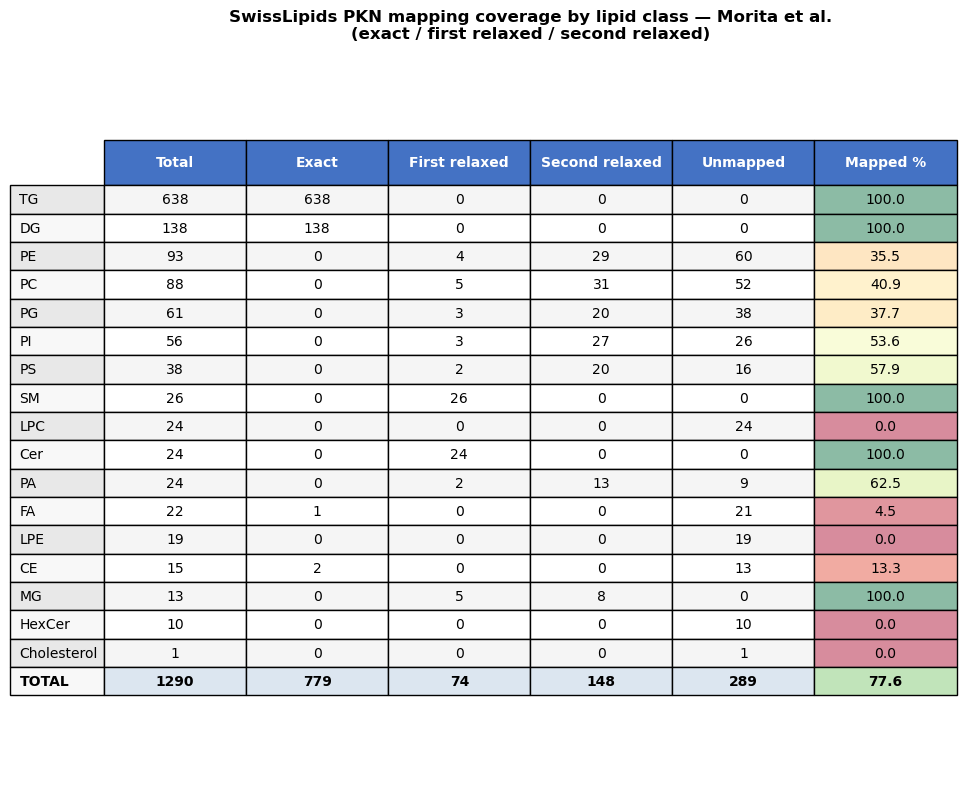

Saved -> ../results/plots/swisslipids_pkn_coverage.png


In [134]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Rebuild cls_summary using mutually exclusive flags ──────────
def class_summary_row(g):
    is_e = g['mapped'].astype(bool)
    is_f = (~g['mapped'].astype(bool)) & g['relaxed_match'].fillna(False).astype(bool)
    is_s = (~g['mapped'].astype(bool)) & (~g['relaxed_match'].fillna(False).astype(bool)) & g['second_relaxed_match'].fillna(False).astype(bool)
    is_no = ~is_e & ~is_f & ~is_s
    total = len(g)
    e, f, s, no = int(is_e.sum()), int(is_f.sum()), int(is_s.sum()), int(is_no.sum())
    return pd.Series({
        'Total':           total,
        'Exact':           e,
        'First relaxed':   f,
        'Second relaxed':  s,
        'Unmapped':        no,
        'Mapped %':        round((e + f + s) / total * 100, 1),
    })

tbl = (
    df.groupby('class_name')
    .apply(class_summary_row)
    .sort_values('Total', ascending=False)
)

# TOTAL row
tot = tbl.sum()
tot['Mapped %'] = round((tot['Exact'] + tot['First relaxed'] + tot['Second relaxed']) / tot['Total'] * 100, 1)
tbl.loc['TOTAL'] = tot

col_labels  = tbl.columns.tolist()
row_labels  = tbl.index.tolist()
cell_values = [[int(v) if i < len(col_labels)-1 else v
                for i, v in enumerate(row)] for row in tbl.values.tolist()]

# ── Colors ──────────────────────────────────────────────────────
cmap        = plt.cm.RdYlGn
pct_col_idx = col_labels.index('Mapped %')
first_col_idx  = col_labels.index('First relaxed')
second_col_idx = col_labels.index('Second relaxed')

def pct_color(val):
    try:
        rgba = cmap(float(val) / 100)
        pastel = tuple(c * 0.45 + 0.55 for c in rgba[:3])
        return mcolors.to_hex(pastel)
    except Exception:
        return '#ffffff'

cell_colors = []
for i, row in enumerate(cell_values):
    cls = row_labels[i]
    base = '#f5f5f5' if i % 2 == 0 else '#ffffff'
    row_c = [base] * len(col_labels)
    row_c[pct_col_idx]    = pct_color(row[pct_col_idx])
    if cls == 'TOTAL':
        row_c = ['#dce6f0'] * len(col_labels)
        row_c[pct_col_idx] = pct_color(row[pct_col_idx])
    cell_colors.append(row_c)

# ── Draw ────────────────────────────────────────────────────────
n_rows = len(row_labels)
fig, ax = plt.subplots(figsize=(11, max(4.0, 0.45 * n_rows + 1.6)))
ax.axis('off')

the_table = ax.table(
    cellText    = cell_values,
    rowLabels   = row_labels,
    colLabels   = col_labels,
    cellColours = cell_colors,
    rowColours  = ['#e8e8e8' if i % 2 == 0 else '#f8f8f8' for i in range(n_rows)],
    colColours  = ['#4472c4'] * len(col_labels),
    loc         = 'center',
    cellLoc     = 'center',
)
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1, 1.7)

# Header
for j in range(len(col_labels)):
    the_table[0, j].set_height(the_table[0, j].get_height() * 1.6)
    the_table[0, j].set_text_props(color='white', fontweight='bold')

# TOTAL row bold
for j in range(-1, len(col_labels)):
    the_table[n_rows, j].set_text_props(fontweight='bold')

ax.set_title(
    'SwissLipids PKN mapping coverage by lipid class — Morita et al.\n'
    '(exact / first relaxed / second relaxed)',
    fontsize=12, fontweight='bold', pad=4,
)

out_path = '../results/plots/swisslipids_pkn_coverage.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {out_path}')
